In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

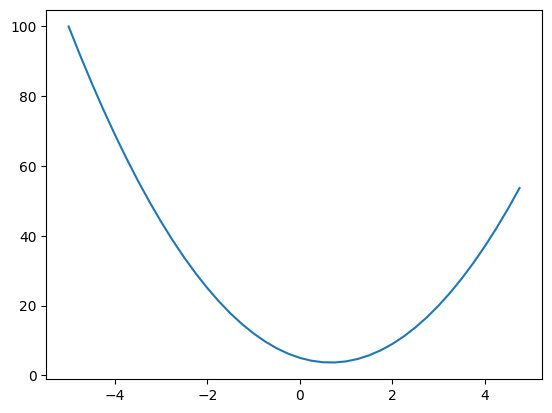

In [3]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys);

In [4]:
h = 0.00001
(f(3+h)-f(3))/h

14.00003000000538

In [5]:
# les get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [6]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h) # derivative of d with respect to a is b, with respect to b is a, with respect to c is 1

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [2]:
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other) # To allow adding constants
        out = Value(self.data + other.data,(self,other),'+')

        def _backward():
            self.grad += 1.0 * out.grad # Cz in case of addition local gradient is 1
            other.grad += 1.0 * out.grad
        
        out._backward = _backward
        return out
    
    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value(other) # To allow multiplying constants
        out = Value(self.data * other.data,(self,other),'*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out
    
    def __rmul__(self,other): # For other*self
        return self*other
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self,other): # self - other
        return self + (-other)
    
    def __radd__(self,other): # For other + self
        return self + other
    
    def __truediv__(self,other):
        return self * other**-1
    
    def __pow__(self,other):
        assert isinstance(other,(int,float)), "Power must be int or float"
        x = self.data
        out = Value(x**other,(self,),f'**{other}')

        def _backward():
            self.grad += other * x**(other-1) * out.grad

        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        t = math.exp(x)
        out = Value(t,(self,),'exp')

        def _backward():
            self.grad += t * out.grad

        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = math.tanh(x) 
        out = Value(t,(self,), 'tanh')
        # data = tanh(data), children = self, operation = tanh

        def _backward():
            self.grad += (1 - t**2) * out.grad # derivative of tanh is 1 - tanh^2

        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0

        for node in reversed(topo):
            node._backward()
    

a = Value(2.0,label='a')
b = Value(-3.0,label='b')
c = Value(10.0,label='c')

e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0,label='f')
L = d * f ; L.label = 'L'
L
    


Value(data=-8.0)

In [28]:
a+b+c

Value(data=9.0)

In [8]:
d._prev, d._op

({Value(data=-6.0), Value(data=10.0)}, '+')

In [3]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label,n.data,n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

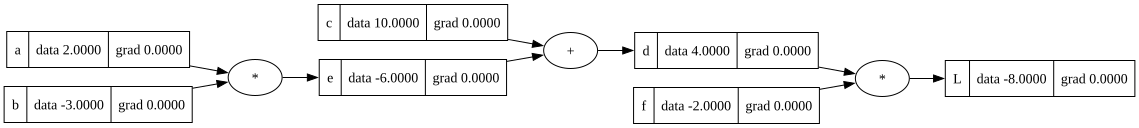

In [20]:
draw_dot(L)

In [57]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

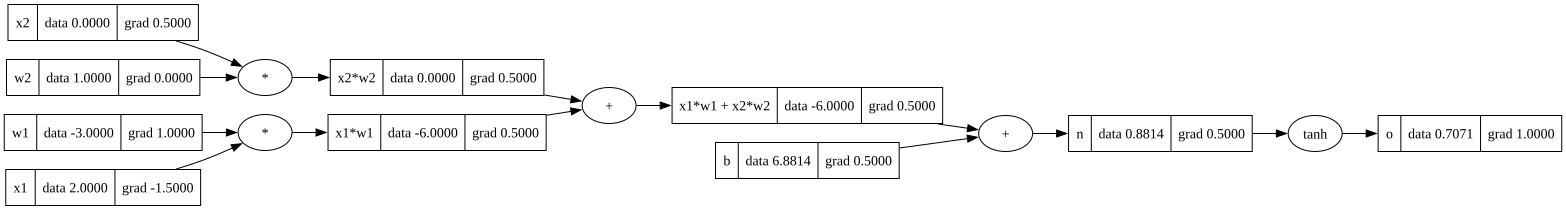

In [60]:
draw_dot(o)

In [59]:
o.backward()

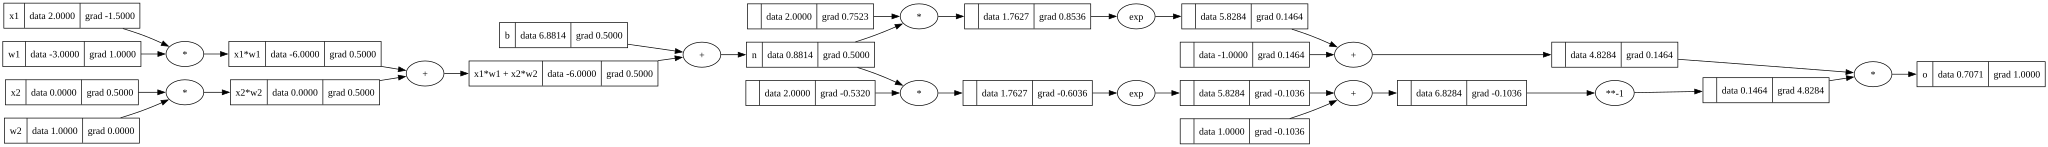

In [29]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
#-------------
o = ((n*2).exp()-1)/((n*2).exp()+1); o.label = 'o'
#-------------
o.backward()
draw_dot(o)

In [48]:
o.grad = 1.0 # we have to set this to 1 cz by default it is 0
o._backward() # This will set the gradients of the children of o

In [50]:
n._backward()

In [ ]:
b._backward() # As b does not have any children, it will not do anything. Cz _backward is set to None by default
x1w1x2w2._backward()

In [54]:
x1w1._backward()
x2w2._backward()

In [27]:
o.grad = 1.0

- `do/dn = 1 - o**2`
- `do/dn = 1 - 0.7071**2 = 0.5`

In [29]:
n.grad = 0.5

In [31]:
x1w1x2w2.grad = 0.5
b.grad = 0.5
# Plus op just passes the gradient to its children

In [33]:
x1w1.grad = 0.5 
x2w2.grad = 0.5

In [37]:
x1.grad = x1w1.grad * w1.data
w1.grad = x1w1.grad * x1.data

x2.grad = x2w2.grad * w2.data
w2.grad = x2w2.grad * x2.data

### Bug if `self.grad = something*out.grad` is used

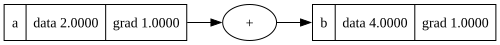

In [5]:
# Example 1
a = Value(2.0,label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

- Grad is overwritten cz `self.grad` is the same as `other.grad`

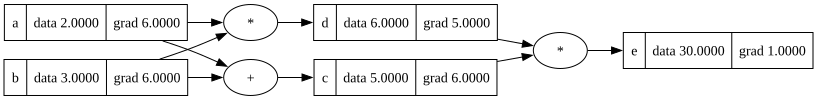

In [7]:
# Example 2
a = Value(2.0,label='a')
b = Value(3.0,label='b')
c = a + b; c.label = 'c'
d = a * b; d.label = 'd'
e = c * d; e.label = 'e'
e.backward()
draw_dot(e)

- Grad of `a` & `b` set by `d` is overwritten by grad of `c`
- This bug can be fixed by using `self.grad += something*out.grad` instead of `self.grad = something*out.grad`

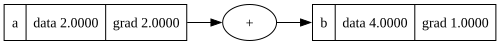

In [24]:
a = Value(2.0,label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

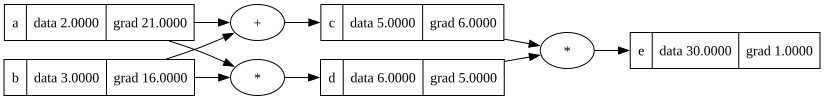

In [10]:
a = Value(2.0,label='a')
b = Value(3.0,label='b')
c = a + b; c.label = 'c'
d = a * b; d.label = 'd'
e = c * d; e.label = 'e'
e.backward()
draw_dot(e)

- The Gradient is now accumulated instead of being overwritten

### Same thing with PyTorch

In [4]:
import torch

In [5]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [6]:
import random

In [27]:
class Neuron:

    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self,x):
        act = sum((wi*xi for wi,xi in zip(self.w,x)),self.b) 
        out = act.tanh() 
        return out

    def parameters(self):
        return self.w + [self.b]
    
class Layer:
    def __init__(self,nin,nout):
         self.neurons = [Neuron(nin) for _ in range(nout)] # Cz we have nout neurons with each of them taking nin i/p in a layer
    
    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs # If only one neuron, return the single value, else return list of values
    
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]
    
class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    
x = [2.0,3.0,-1.0] # 3 i/p
nn = MLP(3,[4,4,1])
y = nn(x) # 1 o/p
y

Value(data=0.028611055673726772)

In [28]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [29]:
ypred = [nn(x) for x in xs] # predicted outputs
loss = sum((yhat - y)**2 for yhat,y in zip(ypred,ys)) # SE loss
loss

Value(data=5.961085254340423)

In [30]:
loss.backward() # Backpropagation

In [ ]:
# Training Loop
for k in range(20):
    # Forward pass
    ypred = [nn(x) for x in xs] # predicted outputs
    loss = sum((yhat - y)**2 for yhat,y in zip(ypred,ys)) # SE loss

    # Backward pass
    for p in nn.parameters():
        p.grad = 0.0 # Reset gradients to 0,must be done before backpropagation

    loss.backward() # Backpropagation

    # Gradient descent step
    for p in nn.parameters():
        p.data -= 0.05 * p.grad # Update weights with learning rate of 0.01

    print(k,loss.data)

0 0.014137749332411397
1 0.01379194525064565
2 0.013461925205884696
3 0.013146653054617962
4 0.012845180400356523
5 0.012556637566193896
6 0.012280225653405865
7 0.012015209537282096
8 0.011760911674161304
9 0.011516706612581184
10 0.011282016117258748
11 0.01105630482785398
12 0.010839076385588588
13 0.010629869970166564
14 0.010428257197369619
15 0.010233839334421528
16 0.010046244795934224
17 0.009865126888124213
18 0.00969016177315838
19 0.009521046629064937


In [36]:
ypred

[Value(data=0.9331367868292327),
 Value(data=-0.9645619762307577),
 Value(data=-0.9496689924395855),
 Value(data=0.9644853058181605)]